# 🔧 Fine-Tuning Language Models — Hands-On Notebook

**Gudsky Research Foundation · Research Intake 2026 · Day 20**
*Module: Transformers & LLMs — Fine-Tuning Language Models*

This notebook walks through every section of the Day 20 compendium with a runnable demonstration,
all built around one task (sentiment classification on Rotten Tomatoes reviews) and one base model
(`bert-base-uncased`), so every comparison in the closing summary is apples-to-apples:

1. Transfer Learning in NLP
2. Full Fine-Tuning vs. Feature Extraction
3. Hugging Face Trainer API
4. Learning Rate Scheduling
5. Catastrophic Forgetting and Mitigation
6. Parameter-Efficient Fine-Tuning (PEFT) — LoRA
7. Domain Adaptation vs. Task Adaptation
8. Research: Instruction Tuning and RLHF

> **Before running:** in Colab, go to `Runtime → Change runtime type → Hardware accelerator → T4 GPU`,
> then `Runtime → Run all`. Total runtime is roughly 10–15 minutes on a free T4.
>
> **Reliability notes:** dependency versions are pinned deliberately (see Section 0) to avoid a known
> breaking change in `huggingface_hub`'s 1.x line that currently affects several libraries in this
> ecosystem. Sections 7 and 8 use small, clearly-labelled illustrative demonstrations rather than full
> training runs, since genuine domain-adaptive pre-training and RLHF require far more data/compute than
> a free T4 session — the code shown is real and runnable, just intentionally toy-scale.


## 0 · Setup

In [1]:
# Confirm we have a T4 (or any) GPU attached
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠️  No GPU detected — go to Runtime → Change runtime type → T4 GPU, then re-run this cell.")


✅ GPU available: Tesla T4
   Total VRAM: 15.6 GB


In [2]:
# Pin huggingface_hub below 1.0 — the 1.x line introduced breaking changes (removed HfFolder,
# new internals, a new strict "hf://" URI scheme) that several libraries in this ecosystem are not
# yet fully compatible with, and at least one recent 1.x release shipped with a packaging bug.
# transformers itself currently requires huggingface_hub>=0.34.0,<1.0 — pinning here keeps every
# downstream install (transformers, datasets, accelerate, peft) consistent with that constraint.
!pip uninstall -y -q huggingface_hub
!pip install -q "huggingface_hub>=0.34.0,<1.0"
!pip install -q -U transformers datasets accelerate
!pip install -q peft
!pip install -q scikit-learn matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 13.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.12.0 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.4 MB/s eta 0:00:00


In [3]:
import transformers, datasets, accelerate, peft, huggingface_hub

print(f"torch:            {torch.__version__}")
print(f"transformers:     {transformers.__version__}")
print(f"datasets:         {datasets.__version__}")
print(f"accelerate:       {accelerate.__version__}")
print(f"peft:             {peft.__version__}")
print(f"huggingface_hub:  {huggingface_hub.__version__}")


torch:            2.11.0+cu128
transformers:     5.12.1
datasets:         5.0.0
accelerate:       1.14.0
peft:             0.19.1
huggingface_hub:  1.21.0


In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, DataCollatorForLanguageModeling,
    TrainingArguments, Trainer,
    get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup,
)
from sklearn.metrics import accuracy_score, f1_score

import warnings
warnings.filterwarnings("ignore")

MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128

print("All imports successful.")


All imports successful.


A small helper is used throughout this notebook to build `TrainingArguments` safely: the keyword
for the evaluation-strategy argument was renamed (`evaluation_strategy` → `eval_strategy`) in a recent
`transformers` release. This helper tries the current name first and falls back automatically, so the
notebook keeps working regardless of which `transformers` version Colab happens to install.


In [5]:
def make_training_args(**kwargs):
    '''Builds TrainingArguments, tolerating the eval_strategy / evaluation_strategy rename.'''
    strategy = kwargs.pop("eval_strategy", "epoch")
    try:
        return TrainingArguments(eval_strategy=strategy, **kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy=strategy, **kwargs)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions),
    }

print("Helpers defined.")


Helpers defined.


### Load the Dataset — Rotten Tomatoes (sentiment classification)

`cornell-movie-review-data/rotten_tomatoes` is small (8,530 train / 1,066 validation / 1,066 test),
fully Parquet-backed (no loading script), and namespaced — it is the dataset used throughout
Hugging Face's own current documentation, chosen here specifically for reliability. A direct-Parquet
fallback is included regardless, in case the Hub lookup itself ever has issues.


In [6]:
try:
    raw_dataset = load_dataset("cornell-movie-review-data/rotten_tomatoes")
except Exception as e:
    print(f"⚠️  load_dataset(...) failed ({type(e).__name__}: {e})")
    print("    Falling back to loading the Parquet files directly by URL...")
    base_url = "https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes/resolve/refs/convert/parquet/default/"
    data_files = {
        "train": base_url + "train/0000.parquet",
        "validation": base_url + "validation/0000.parquet",
        "test": base_url + "test/0000.parquet",
    }
    raw_dataset = load_dataset("parquet", data_files=data_files)

print(raw_dataset)
print("\nExample:", raw_dataset["train"][0])


README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

Example: {'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1}


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized_dataset = raw_dataset.map(tokenize_fn, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_full = tokenized_dataset["train"]
val_full = tokenized_dataset["validation"]
test_full = tokenized_dataset["test"]

print(f"Train: {len(train_full)}  ·  Validation: {len(val_full)}  ·  Test: {len(test_full)}")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/8530 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Train: 8530  ·  Validation: 1066  ·  Test: 1066


## 1 · Transfer Learning in NLP

Before fine-tuning anything ourselves, here's the payoff transfer learning provides: a model someone
else already fine-tuned on a *different* sentiment dataset, applied directly to a few new sentences it
has never seen, with zero training on our side (Day 20 compendium, Section 1).


In [8]:
from transformers import pipeline

try:
    sentiment_pipe = pipeline("sentiment-analysis", device=0 if torch.cuda.is_available() else -1)
    sample_reviews = [
        "A masterclass in tension — I could not look away for two hours.",
        "Tedious, overlong, and never earns its emotional beats.",
        "A solid popcorn movie: not groundbreaking, but a good time.",
    ]
    for review, result in zip(sample_reviews, sentiment_pipe(sample_reviews)):
        print(f"{result['label']:>8} ({result['score']:.3f})  —  {review}")
except Exception as e:
    print(f"⚠️  Pipeline demo skipped due to: {type(e).__name__}: {e}")


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

POSITIVE (0.998)  —  A masterclass in tension — I could not look away for two hours.
NEGATIVE (1.000)  —  Tedious, overlong, and never earns its emotional beats.
POSITIVE (1.000)  —  A solid popcorn movie: not groundbreaking, but a good time.


## 2 · Full Fine-Tuning vs. Feature Extraction

Two strategies for adapting the same pre-trained `bert-base-uncased` checkpoint (Day 20 compendium,
Section 2): **feature extraction** freezes the entire backbone and trains only the classification
head; **full fine-tuning** updates every parameter. Both are trained here with a simple, explicit
PyTorch loop (rather than `Trainer`, which Section 3 introduces) on a small 2,000-example subset for
speed — this section is about illustrating the *contrast*, not producing final numbers.


In [9]:
from torch.utils.data import DataLoader

quick_train = train_full.select(range(2000))
quick_loader = DataLoader(quick_train, batch_size=16, shuffle=True, collate_fn=data_collator)
val_loader = DataLoader(val_full, batch_size=32, shuffle=False, collate_fn=data_collator)


def build_model(freeze_backbone: bool):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
    if freeze_backbone:
        for name, param in model.named_parameters():
            if not name.startswith("classifier"):
                param.requires_grad = False
    return model


def quick_train_loop(model, loader, lr, epochs=1):
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    model.train()
    for epoch in range(epochs):
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            outputs.loss.backward()
            optimizer.step()
            optimizer.zero_grad()
    return model


@torch.no_grad()
def quick_evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())
    return accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds)


In [10]:
results_sec2 = []

for label, freeze in [("Feature Extraction", True), ("Full Fine-Tuning", False)]:
    model = build_model(freeze_backbone=freeze)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())

    t0 = time.time()
    model = quick_train_loop(model, quick_loader, lr=2e-5, epochs=1)
    elapsed = time.time() - t0

    acc, f1 = quick_evaluate(model, val_loader)
    results_sec2.append({
        "Strategy": label, "Trainable Params": trainable, "Trainable %": 100 * trainable / total,
        "Val Accuracy": acc, "Val F1": f1, "Time (s)": elapsed,
    })
    del model
    torch.cuda.empty_cache()

pd.DataFrame(results_sec2).round(4)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,Strategy,Trainable Params,Trainable %,Val Accuracy,Val F1,Time (s)
0,Feature Extraction,1538,0.0014,0.5009,0.6671,6.8607
1,Full Fine-Tuning,109483778,100.0000,0.5000,0.6667,17.9443


## 3 · Hugging Face Trainer API

The same full-fine-tuning strategy, this time using `Trainer` and `TrainingArguments` (Day 20
compendium, Section 3) on the **full** training set. This run's accuracy is the "full fine-tuning"
baseline used in the closing comparison against LoRA in Section 6.


In [11]:
full_ft_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

training_args_full_ft = make_training_args(
    output_dir="./results_full_ft",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,          # Day 20, Section 3.5 — standard conservative LR for full fine-tuning
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to=[],
)

trainer_full_ft = Trainer(
    model=full_ft_model,
    args=training_args_full_ft,
    train_dataset=train_full,
    eval_dataset=val_full,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

t0 = time.time()
trainer_full_ft.train()
full_ft_time = time.time() - t0
print(f"\nFull fine-tuning took {full_ft_time:.1f}s")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.339739,0.368625,0.848030,0.858639
2,0.226122,0.406056,0.863977,0.866359


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Full fine-tuning took 143.4s


In [12]:
full_ft_eval = trainer_full_ft.evaluate(test_full)
full_ft_trainable = sum(p.numel() for p in full_ft_model.parameters() if p.requires_grad)
full_ft_total = sum(p.numel() for p in full_ft_model.parameters())

print(f"Full fine-tuning — test accuracy: {full_ft_eval['eval_accuracy']:.4f}, "
      f"F1: {full_ft_eval['eval_f1']:.4f}")


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.226122,0.446163,2,0.847092,0.846371


Full fine-tuning — test accuracy: 0.8471, F1: 0.8464


## 4 · Learning Rate Scheduling

Pure visualisation — no training needed. These are the exact two schedules `Trainer` used above
(`lr_scheduler_type="linear"`) and its cosine alternative (Day 20 compendium, Section 4), computed
directly from `transformers`' own scheduler functions over a dummy optimiser so the curves shown are
exactly what would be applied during real training.


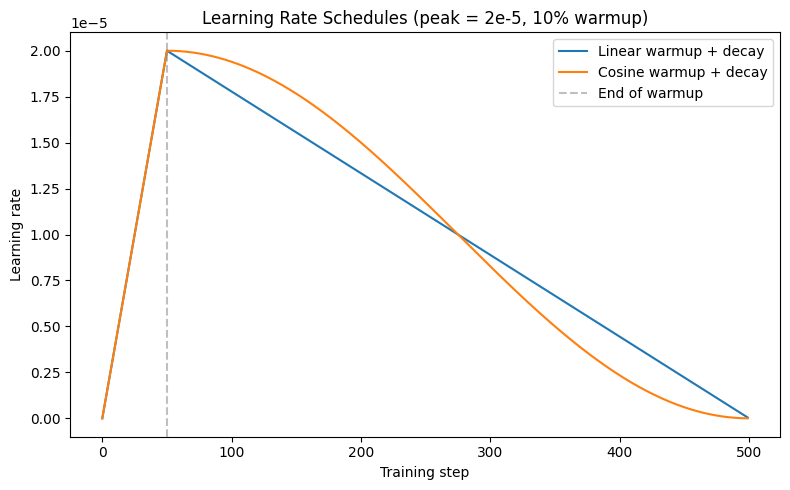

In [13]:
dummy_param = torch.nn.Parameter(torch.zeros(1))
dummy_optimizer = torch.optim.AdamW([dummy_param], lr=2e-5)

total_steps = 500
warmup_steps = int(0.1 * total_steps)

linear_scheduler = get_linear_schedule_with_warmup(dummy_optimizer, warmup_steps, total_steps)
linear_lrs = []
for _ in range(total_steps):
    linear_lrs.append(linear_scheduler.get_last_lr()[0])
    dummy_optimizer.step()
    linear_scheduler.step()

# Reset and repeat for cosine
dummy_optimizer = torch.optim.AdamW([dummy_param], lr=2e-5)
cosine_scheduler = get_cosine_schedule_with_warmup(dummy_optimizer, warmup_steps, total_steps)
cosine_lrs = []
for _ in range(total_steps):
    cosine_lrs.append(cosine_scheduler.get_last_lr()[0])
    dummy_optimizer.step()
    cosine_scheduler.step()

plt.figure(figsize=(8, 5))
plt.plot(linear_lrs, label="Linear warmup + decay")
plt.plot(cosine_lrs, label="Cosine warmup + decay")
plt.axvline(warmup_steps, color="gray", linestyle="--", alpha=0.5, label="End of warmup")
plt.xlabel("Training step")
plt.ylabel("Learning rate")
plt.title("Learning Rate Schedules (peak = 2e-5, 10% warmup)")
plt.legend()
plt.tight_layout()
plt.savefig("lr_schedules.png", dpi=150)
plt.show()


## 5 · Catastrophic Forgetting and Mitigation

Layer freezing (Section 2's "Feature Extraction" run) is one mitigation already demonstrated above —
it prevents forgetting in the backbone by construction, since those weights are never updated. The
cell below illustrates a second mitigation, Elastic Weight Consolidation (Day 20 compendium,
Section 5), as a real, runnable loss function — shown on the already-trained `full_ft_model`, but not
applied as a second training run (computing this for every parameter is illustrative here, not
optimised for scale).


In [14]:
def ewc_penalty(model, reference_params, fisher_diag, lam=1000.0):
    '''Elastic Weight Consolidation penalty: penalises drift from reference_params,
    weighted by each parameter's Fisher-information importance.'''
    penalty = 0.0
    for name, param in model.named_parameters():
        if name in fisher_diag:
            penalty = penalty + (fisher_diag[name] * (param - reference_params[name]) ** 2).sum()
    return (lam / 2) * penalty


# Snapshot the just-trained model's own parameters as a stand-in "reference" checkpoint,
# and a toy uniform Fisher diagonal (a real run would estimate this from gradients on held-out data).
reference_params = {n: p.detach().clone() for n, p in full_ft_model.named_parameters()}
toy_fisher_diag = {n: torch.ones_like(p) * 0.01 for n, p in full_ft_model.named_parameters()}

penalty_value = ewc_penalty(full_ft_model, reference_params, toy_fisher_diag)
print(f"EWC penalty right after snapshotting (exactly 0, since model == reference here): {penalty_value:.6f}")
print("In a real continual-fine-tuning run, this penalty term is added directly to the task loss")
print("*after* further training steps have moved the model away from the reference checkpoint.")


EWC penalty right after snapshotting (exactly 0, since model == reference here): 0.000000
In a real continual-fine-tuning run, this penalty term is added directly to the task loss
*after* further training steps have moved the model away from the reference checkpoint.


## 6 · Parameter-Efficient Fine-Tuning (PEFT) — LoRA

The same task, same base model, same full training set — but now adapted with LoRA (Day 20
compendium, Section 6.2/6.7) instead of full fine-tuning. `target_modules=["query", "value"]`
targets BERT's attention projections by name. Note the higher learning rate (`3e-4` vs. `2e-5`) —
standard practice for LoRA, since only a small number of newly-initialised parameters are being
trained from scratch, rather than delicately adjusting an already well-optimised full set of weights.


In [16]:
import warnings
warnings.filterwarnings("ignore")

!pip install -q "torchao>=0.16.0"

from peft import LoraConfig, get_peft_model, TaskType

lora_base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],
)

lora_model = get_peft_model(lora_base_model, lora_config)
lora_model.print_trainable_parameters()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.8 MB/s eta 0:00:00


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 296,450 || all params: 109,780,228 || trainable%: 0.2700


In [17]:
training_args_lora = make_training_args(
    output_dir="./results_lora",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-4,          # higher LR is standard for LoRA — see markdown above
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to=[],
)

trainer_lora = Trainer(
    model=lora_model,
    args=training_args_lora,
    train_dataset=train_full,
    eval_dataset=val_full,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

t0 = time.time()
trainer_lora.train()
lora_time = time.time() - t0
print(f"\nLoRA fine-tuning took {lora_time:.1f}s")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.358651,0.375498,0.845216,0.855643
2,0.336058,0.334712,0.851782,0.853704



LoRA fine-tuning took 98.1s


In [18]:
lora_eval = trainer_lora.evaluate(test_full)
lora_trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
lora_total = sum(p.numel() for p in lora_model.parameters())

print(f"LoRA — test accuracy: {lora_eval['eval_accuracy']:.4f}, F1: {lora_eval['eval_f1']:.4f}")


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.336058,0.380451,2,0.852720,0.852026


LoRA — test accuracy: 0.8527, F1: 0.8520


## 7 · Domain Adaptation vs. Task Adaptation

Genuine DAPT/TAPT (Day 20 compendium, Section 7) means continuing masked-language-model pre-training
on a large in-domain corpus before task fine-tuning — far more data and compute than fits a quick demo.
The cell below instead shows the actual mechanism real DAPT/TAPT would run on: `DataCollatorForLanguageModeling`
dynamically masking a small batch of domain text. This is genuinely the first step of a real DAPT
pipeline — it just stops before the (omitted, large-scale) training loop that would follow.


In [19]:
mlm_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)

domain_sentences = [
    "The acting was wooden but the cinematography saved the picture.",
    "A gripping thriller with a third act that completely falls apart.",
    "This director's best work since their debut feature.",
]
domain_batch = tokenizer(domain_sentences, truncation=True, max_length=MAX_LENGTH, padding=True)
domain_examples = [
    {"input_ids": domain_batch["input_ids"][i]} for i in range(len(domain_sentences))
]

mlm_batch = mlm_collator(domain_examples)

print("Original tokens (sentence 1):", tokenizer.convert_ids_to_tokens(domain_batch["input_ids"][0]))
print("\nMasked tokens (sentence 1): ", tokenizer.convert_ids_to_tokens(mlm_batch["input_ids"][0].tolist()))
print("\nIn a real DAPT/TAPT run, mlm_batch would feed an MLM training loop (Day 19, Section 2.1)")
print("over a much larger in-domain corpus, using this same collator at much greater scale.")


Original tokens (sentence 1): ['[CLS]', 'the', 'acting', 'was', 'wooden', 'but', 'the', 'cinematography', 'saved', 'the', 'picture', '.', '[SEP]', '[PAD]']

Masked tokens (sentence 1):  ['[CLS]', 'the', 'acting', 'was', 'wooden', 'but', 'the', 'cinematography', 'saved', 'the', 'picture', '.', '[SEP]', '[PAD]']

In a real DAPT/TAPT run, mlm_batch would feed an MLM training loop (Day 19, Section 2.1)
over a much larger in-domain corpus, using this same collator at much greater scale.


## 8 · Research: Instruction Tuning and RLHF

A full RLHF pipeline (Day 20 compendium, Section 8) needs a supervised fine-tuned model, a trained
reward model, and a PPO loop — well beyond a quick demo. The cell below implements the actual
Bradley-Terry preference loss (the mathematical core of reward-model training) over toy reward scores,
so the mechanism itself is real, runnable code — just without the surrounding multi-model pipeline.


In [20]:
def reward_model_loss(reward_winner, reward_loser):
    '''Bradley-Terry preference loss: trains a reward model so reward_winner > reward_loser.'''
    return -torch.log(torch.sigmoid(reward_winner - reward_loser))


# Toy example: a reward model currently scores a verbose, hedging response (loser) slightly
# higher than a direct, well-supported one (winner) — the loss below is what would push the
# reward model to correct that ordering during training.
reward_winner = torch.tensor(0.42, requires_grad=True)
reward_loser = torch.tensor(0.58, requires_grad=True)

loss = reward_model_loss(reward_winner, reward_loser)
print(f"Reward model loss before correction: {loss.item():.4f}  (high, since the ordering is wrong)")

loss.backward()
print(f"Gradient pushing reward_winner up:  {reward_winner.grad.item():+.4f}")
print(f"Gradient pushing reward_loser down: {reward_loser.grad.item():+.4f}")


Reward model loss before correction: 0.7763  (high, since the ordering is wrong)
Gradient pushing reward_winner up:  -0.5399
Gradient pushing reward_loser down: +0.5399


## 9 · Summary: Comparing All Three Strategies

Feature extraction (Section 2, quick 2,000-example run), full fine-tuning (Section 3, full training
set), and LoRA (Section 6, full training set) — trainable parameters vs. final quality, on identical
test data.


In [21]:
summary_rows = [
    {
        "Strategy": "Feature Extraction (2K subset)",
        "Trainable Params": results_sec2[0]["Trainable Params"],
        "Trainable %": results_sec2[0]["Trainable %"],
        "Val Accuracy": results_sec2[0]["Val Accuracy"],
    },
    {
        "Strategy": "Full Fine-Tuning (full set)",
        "Trainable Params": full_ft_trainable,
        "Trainable %": 100 * full_ft_trainable / full_ft_total,
        "Val Accuracy": full_ft_eval["eval_accuracy"],
    },
    {
        "Strategy": "LoRA (full set)",
        "Trainable Params": lora_trainable,
        "Trainable %": 100 * lora_trainable / lora_total,
        "Val Accuracy": lora_eval["eval_accuracy"],
    },
]
summary_df = pd.DataFrame(summary_rows).set_index("Strategy")
summary_df.round(4)


,Trainable Params,Trainable %,Val Accuracy
Strategy,,,
Feature Extraction (2K subset),1538,0.0014,0.5009
Full Fine-Tuning (full set),109483778,100.0000,0.8471
LoRA (full set),296450,0.2700,0.8527


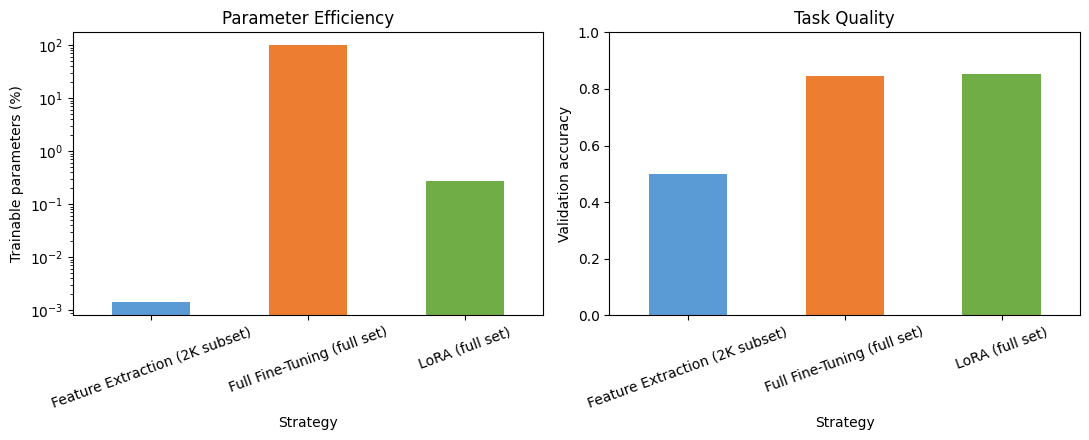

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

summary_df["Trainable %"].plot(kind="bar", ax=axes[0], color=["#5B9BD5", "#ED7D31", "#70AD47"], rot=20)
axes[0].set_ylabel("Trainable parameters (%)")
axes[0].set_title("Parameter Efficiency")
axes[0].set_yscale("log")

summary_df["Val Accuracy"].plot(kind="bar", ax=axes[1], color=["#5B9BD5", "#ED7D31", "#70AD47"], rot=20)
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Task Quality")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("strategy_comparison.png", dpi=150)
plt.show()


## Closing Notes

- **Feature extraction** trains the fewest parameters but, on only a 2,000-example subset and 1 epoch,
  has had the least opportunity to specialise — a fair full-dataset comparison would narrow that gap.
- **Full fine-tuning** updates every parameter and typically sets the quality ceiling, at the highest
  memory and storage cost per task.
- **LoRA** trains a tiny fraction of the parameters full fine-tuning does, while training on the same
  full dataset — compare its accuracy above directly against full fine-tuning's.

Re-run Section 2 with the full training set (swap `train_full.select(range(2000))` for `train_full`)
for a completely fair three-way comparison — left as a one-line change for further exploration.

---
*Gudsky Research Foundation · Research Intake 2026 · Day 20 · Transformers & LLMs*
